In [10]:
from quspin.operators import hamiltonian, exp_op, quantum_operator # Hamiltonians and operators
from quspin.basis import spin_basis_1d # Hilbert space spin basis
from quspin.tools.measurements import ent_entropy

import numpy as np # generic math functions
from numpy import linalg as LA
import scipy.sparse as sp
from scipy.linalg import logm, expm, sinm, cosm, svd
from scipy.sparse.linalg import eigs, eigsh
from scipy.sparse.linalg import expm, expm_multiply
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline
from scipy.stats import linregress

import time
import copy
import numba as nb
import matplotlib.pyplot as plt
import functools as ft
import scienceplots
import math
import random
from scipy.stats import unitary_group
import itertools
from joblib import Parallel, delayed
from scipy.linalg import svd
import json

%load_ext memory_profiler
plt.style.use(['science','notebook', 'grid'])

The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler


In [11]:
def Fredkin_Ham_bd(L,i,j):
    basis = spin_basis_1d(L,S='1/2',pauli=1)
    First_term_I = [[1/2, i]]
    Last_term_I = [[1/2, j]]
    First_term_z = [[-1.0/2, i]]
    Last_term_z = [[1.0/2, j]]
    static = [["I",First_term_I],["z",First_term_z],["I",First_term_I],["z",Last_term_z]]
    dynamic =[]
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

def Fredkin_Ham_bulk(L,j):
    basis = spin_basis_1d(L,S='1/2',pauli=1)
    III = [[2.0/8,i,i+1,i+2] for i in range(j,L-2)]
    Iaa = [[-1.0/8,i,i+1,i+2] for i in range(j,L-2)]
    zII = [[1.0/8,i,i+1,i+2] for i in range(j,L-2)]
    zaa = [[-1.0/8,i,i+1,i+2] for i in range(j,L-2)]
    IIz = [[-1.0/8,i,i+1,i+2] for i in range(j,L-2)]
    aaI = [[-1.0/8,i,i+1,i+2] for i in range(j,L-2)]
    aaz = [[1.0/8,i,i+1,i+2] for i in range(j,L-2)]
    static = [["III",III],["Ixx",Iaa],["Iyy",Iaa],["Izz",Iaa],["zII",zII],["zxx",zaa],["zyy",zaa],["IIz",IIz],["xxI",aaI],["yyI",aaI],["zzI",aaI],["xxz",aaz],["yyz",aaz]]
    dynamic = []
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

def Fredkin_Ham_total(L):
    return Fredkin_Ham_bd(L,0,L-1) + Fredkin_Ham_bulk(L,0)

def Fredkin_Ham_PBC(L):
    basis = spin_basis_1d(L,S='1/2',pauli=1)
    III = [[1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    Iaa = [[-1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    zII = [[1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    zaa = [[-1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    III_1 = [[1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    aaI = [[-1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    IIz = [[-1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    aaz = [[1.0/8,i,(i+1)%L,(i+2)%L] for i in range(L)]
    static = [["III",III],["Ixx",Iaa],["Iyy",Iaa],["Izz",Iaa],["zII",zII],["zxx",zaa],["zyy",zaa],["zzz",zaa],["III",III_1],["xxI",aaI],["yyI",aaI],["zzI",aaI],["IIz",IIz],["xxz",aaz],["yyz",aaz],["zzz",aaz]]
    dynamic = []
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

In [12]:
#Time evolution
def evol_op (H, at,start_time, end_time, time_step):
    return exp_op(H,a=at*(-1j),start=start_time,stop=end_time,num=time_step,endpoint=True,iterate=False)

def timestepN(starttime, endtime, deltat):
    return (endtime-starttime)/deltat

def timesteplistT(starttime, endtime, no_steps):
    timelistT = []
    for i in range(no_steps):
        tel = starttime + i*((endtime-starttime)/(no_steps-1))
        timelistT.append(tel)
    return timelistT

In [13]:
#Neel, Dimer, Spinon states, Spin correlation observables, Neel Obs, VBS Obs
up = np.array([1.0,0.0])
dn = np.array([0.0,1.0])
mg = (1/np.sqrt(2))*(np.kron(up,dn)-np.kron(dn,up))
mg1 = (1/np.sqrt(2))*(np.kron(dn,up)-np.kron(up,dn))

#Neel state
def allup(L):
    state =[]
    for i in range(L):
        state.append(up)
    return ft.reduce(np.kron,state)

def alldown(L):
    state = []
    for i in range(L):
        state.append(dn)
    return ft.reduce(np.kron,state)

def neel(L):
    state = []
    for i in range(L):
        if (i+1)%2 == 1:
            state.append(up)
        if (i+1)%2 == 0:
            state.append(dn)
    return ft.reduce(np.kron,state)
#Dimer state
def MGstate(L):
    state =[]
    for i in range(int(L/2)):
        state.append(mg)
    return ft.reduce(np.kron,state)

def MGstate1(L):
    state =[]
    for i in range(int(L/2)):
        state.append(mg1)
    return ft.reduce(np.kron,state)

#Domain wall
def domainwallnew(L):
    state = []
    for i in range(L):
        if i+1 <= int(L/2):
            state.append(up)
        if i+1 > int(L/2):
            state.append(dn)
    return ft.reduce(np.kron,state)
    #return state
    
def domainwall_state_1(L):
    state = []
    for i in range(L):
        if i <= L//2:
            state.append('up')
        if i > L//2:
            state.append('dn')
    #return ft.reduce(np.kron,state)
    return state

def random_product_state(L):
    state = []
    for i in range(L):
        RandomUnitary = unitary_group.rvs(2)
        random_two_state = RandomUnitary.dot(up)
        state.append(random_two_state)
    return ft.reduce(np.kron,state)
 

#Spin operators x, y, z at i-th site
def spinopx(N,i):
    basisq = spin_basis_1d(N,pauli=0)
    spincoeff = [[1.0, i]]
    return hamiltonian([['x', spincoeff]],[], basis=basisq, check_herm=False, check_symm=False)

def spinopy(N,i):
    basisq = spin_basis_1d(N,pauli=0)
    spincoeff = [[1.0, i]]
    return hamiltonian([['y', spincoeff]],[], basis=basisq, check_herm=False, check_symm=False)

def spinopz(N,i):
    basisq = spin_basis_1d(N,pauli=0)
    spincoeff = [[1.0, i]]
    return hamiltonian([['z', spincoeff]],[], basis=basisq, check_herm=False, check_symm=False)

def spinopx_pauli(N,i):
    basisq = spin_basis_1d(N,pauli=1)
    spincoeff = [[1.0, i]]
    return hamiltonian([['x', spincoeff]],[], basis=basisq, check_herm=False, check_symm=False)

def spinopy_pauli(N,i):
    basisq = spin_basis_1d(N,pauli=1)
    spincoeff = [[1.0, i]]
    return hamiltonian([['y', spincoeff]],[], basis=basisq, check_herm=False, check_symm=False)

def spinopz_pauli(N,i):
    basisq = spin_basis_1d(N,pauli=1)
    spincoeff = [[1.0, i]]
    return hamiltonian([['z', spincoeff]],[], basis=basisq, check_herm=False, check_symm=False)

#Magnetization observable, Neel observables and VBS observables

def magnetizationobs(L):
    basis = spin_basis_1d(L,pauli=0)
    S_z = [[(1/L),i] for i in range(L)] #PBC
    static = [["z",S_z]]
    dynamic=[]
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

def neelobservable(L):
    basis = spin_basis_1d(L,pauli=0)
    S_z = [[(1/L)*(-1)**(i+1),i] for i in range(L)] #PBC
    static = [["z",S_z]]
    dynamic=[]
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_symm=False)

def domainwallobservable(L):
    basis = spin_basis_1d(L,pauli=0)
    D_z =[]
    for i in range(L):
        if i < L//2:
            D_z.append([(1/L)*1.0,i])
        if i >= L//2:
            D_z.append([(1/L)*(-1.0),i])
    static = [["z", D_z]]
    dynamic=[]
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_herm=False,check_symm=False)

def domainwallnumber(L):
    basis = spin_basis_1d(L,pauli=1)
    II = [[1.0,i,i+1] for i in range(L-1)]
    zz = [[-1.0,i,i+1] for i in range(L-1)]
    static = [["II",II],["zz",zz]]
    dynamic = []
    return hamiltonian(static,dynamic,basis=basis,dtype=np.float64,check_herm=False,check_symm=False)

In [14]:
def projop(N,i,d):
    basisq = spin_basis_1d(N,pauli=0)
    aterm = [[0.5, i]]
    if d == 0:
        bterm = [[1.0, i]]
    if d == 1:
        bterm = [[-1.0, i]]
    static = [['I', aterm], ['z', bterm]]
    return hamiltonian(static,[], basis=basisq, check_herm=False, check_symm=False)

def identityop(N,i):
    basisq = spin_basis_1d(N,pauli=0)
    aterm = [[1.0, i]]
    static = [['I', aterm]]
    return hamiltonian(static,[], basis=basisq, check_herm=False, check_symm=False)

def leftblock(L):
    lkk = []
    for i in range(L//2):
        lkk.append(i)
    return lkk

def centralblock(L):
    lkkk=[]
    for i in range(int(L/4),int(3*L/4)):
        lkkk.append(i)
    return lkkk    

In [19]:
N = 12
FredkinHam = Fredkin_Ham_total(N)
basis = spin_basis_1d(N,S='1/2',pauli=0)

Hermiticity check passed!
Hermiticity check passed!


In [20]:
#spinsiteA = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
#spinsiteB = [0, 1, 2, 3, 4, 15, 16, 17, 18, 19]

initial_state = domainwallnew(N)

#initial_state = neel(N)
#initial_state = random_product_state(N)
#initial_state = unitary_group.rvs(2**N).dot(allup(N))

In [26]:
#spinsite_1 = [8, 9, 10]

#spinsite_1 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

spinsite_1 = leftblock(N)
spinsite_2 = centralblock(N)
print(spinsite_1)
print(spinsite_2)

L = len(spinsite_1)
#spinsite_1 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
#spinsite_2 = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

[0, 1, 2, 3, 4, 5]
[3, 4, 5, 6, 7, 8]


In [22]:
#timelist = ntt
Hamtt = FredkinHam
spinsitec = spinsite_1
t = 0.1
Nstep = 500
alpha = 2.0
evolved_state = initial_state
tlist = []
Sentlist = []

for step in range(Nstep):
    evolved_state = np.squeeze(np.transpose(evol_op(Hamtt,1.0,t,t,1).dot(evolved_state)))
    S_ent_1 = basis.ent_entropy(evolved_state,sub_sys_A=spinsitec,density = False,return_rdm="A",enforce_pure=False,return_rdm_EVs=True,sparse=True,alpha=alpha,sparse_diag=True,subsys_ordering=True)
    S_ent_f_1 = float(S_ent_1['Sent_A'])
    tmm = t*(step+1)
    tlist.append(tmm)
    Sentlist.append(S_ent_f_1)

Text(0.5, 1.0, 'N = 12, Subsystem size = 6, initial domain wall')

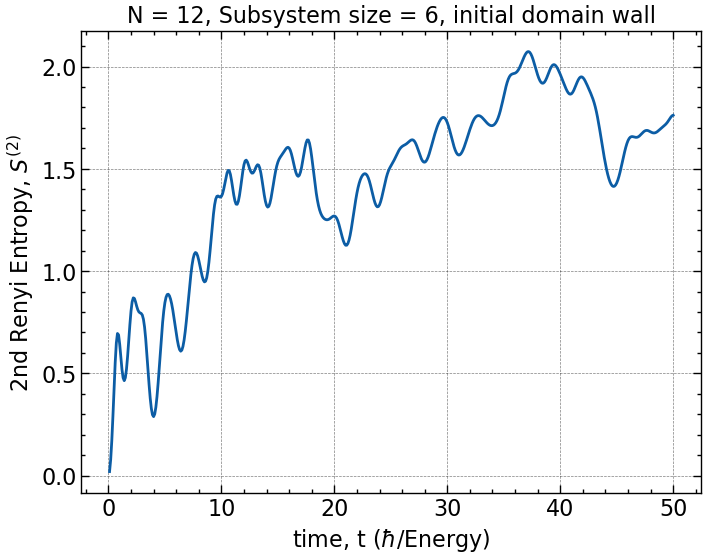

In [28]:
plt.plot(tlist, Sentlist)
plt.xlabel('time, t ($\hbar$/Energy)')
plt.ylabel('2nd Renyi Entropy, $S^{(2)}$')
plt.title(f'N = {N}, Subsystem size = {L}, initial domain wall') 